# Synthetic Data Generator

We use different japanese fonts and data augmentation to create enough data samples to match the ones in ETL9B (around 200)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

FONT_DIR  = Path("drive/MyDrive/ETL9B/Fonts")
FONT_PATHS = sorted(
    p for p in FONT_DIR.rglob("*")
    if p.suffix.lower() in (".ttf", ".otf")
)
print(f"Found {len(FONT_PATHS)} font(s):")
for p in FONT_PATHS:
    print(f"  {p.name}")

Found 6 font(s):
  Kei_Ji.ttf
  Keiji.ttf
  NewClear-mincho.ttf
  NotoSansJP-Medium.ttf
  YorutegakiRegular.otf
  koyomiyuru.ttf


In [ ]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import numpy as np
import random, os
import matplotlib.pyplot as plt


IMG_W, IMG_H   = 63, 64
SAMPLES_PER_CHAR = 206

#These characters don't exist in ETL9B but are necessary for most written japanese
#Somestuff to point out: If the japanese text is vertically oriented, then these guys「", "」" are rotated 90deg.
#Either solve this (not much gain) or we can just exclude this specific case from tests
#Some punctiation is still missing

CHARACTERS = [
    "、", "。", "？", "！", "「", "」", #5
    "ア", "イ", "ウ", "エ", "オ", #10
    "カ", "ガ", "キ", "ギ", "ク", "グ", "ケ", "ゲ", "コ", "ゴ", #20
    "サ", "ザ", "シ", "ジ", "ス", "ズ", "セ", "ゼ", "ソ", "ゾ", #30
    "タ", "ダ", "チ", "ヂ", "ツ", "ヅ", "テ", "デ", "ト", "ド", #40
    "ナ", "ニ", "ネ", "ノ", #44
    "ハ", "バ", "パ", "ヒ", "ビ", "ピ", "フ", "ブ", "プ", "ヘ", "ベ", "ペ", "ホ", "ボ", "ポ", #59
    "マ", "ミ", "ム", "メ", "モ",
    "ヤ", "ユ", "ヨ",
    "ラ", "リ", "ル", "レ", "ロ",
    "ワ", "ン",
    "ヴ"
]

CENTERED_CHARS = ["、", "。"]



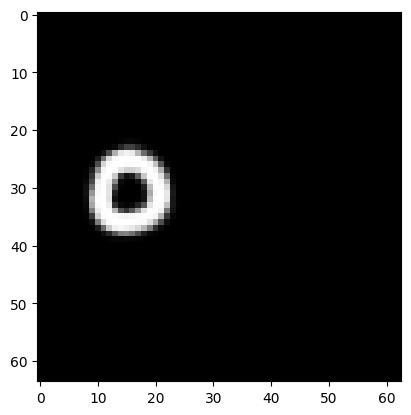

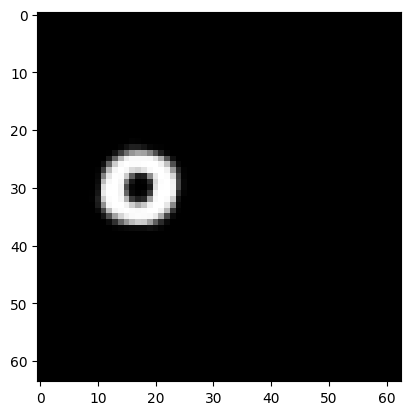

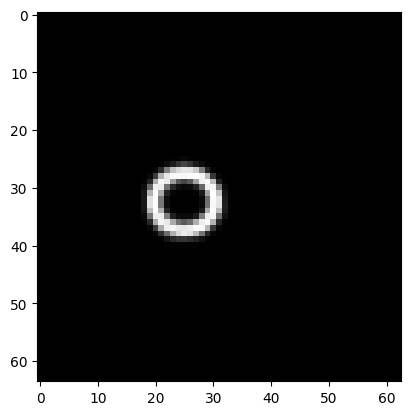

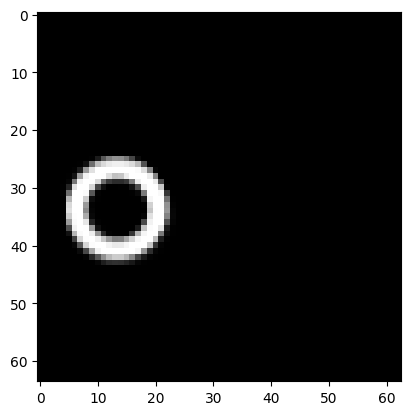

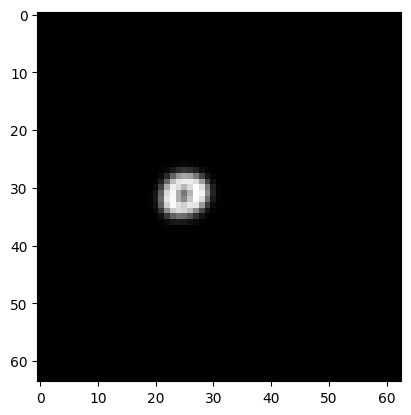

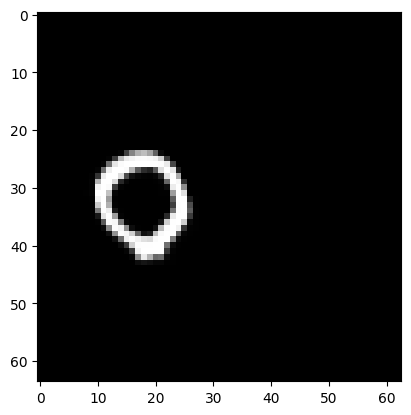

In [ ]:
def ShowImage(img):
    plt.imshow(img, cmap="binary_r")
    plt.show()
 
def CenterInk(binary_arr):
    rows = np.any(binary_arr, axis=1)   
    cols = np.any(binary_arr, axis=0) 

    if not rows.any():
        return binary_arr 

    row_min, row_max = np.where(rows)[0][[0, -1]]
    col_min, col_max = np.where(cols)[0][[0, -1]]

    crop = binary_arr[row_min:row_max+1, col_min:col_max+1]
    ink_h, ink_w = crop.shape

    H, W   = binary_arr.shape
    out    = np.zeros_like(binary_arr)
    off_y  = (H - ink_h) // 2
    off_x  = (W - ink_w) // 2
    out[off_y:off_y+ink_h, off_x:off_x+ink_w] = crop

    return out
   
def RenderCharacter(char, font_path, augment=True):
    font_size = int(IMG_H * random.uniform(0.75, 0.92)) if augment else int(IMG_H * 0.85)
    font = ImageFont.truetype(font_path, font_size)

    canvas = Image.new("L", (IMG_W * 2, IMG_H * 2), color=255)
    draw = ImageDraw.Draw(canvas)
    bbox = draw.textbbox((0, 0), char, font=font)
    char_w = bbox[2] - bbox[0]
    char_h = bbox[3] - bbox[1]


    x = (IMG_W - char_w) // 2 - bbox[0]
    y = (IMG_H - char_h) // 2 - bbox[1]

    if augment:
        x += random.randint(-2, 2)
        y += random.randint(-2, 2)

    img  = Image.new("L", (IMG_W, IMG_H), color=255)
    draw = ImageDraw.Draw(img)
    draw.text((x, y), char, fill=0, font=font)

    if augment:
        angle = random.uniform(-5, 5)
        img   = img.rotate(angle, fillcolor=255, resample=Image.BILINEAR)

        if random.random() < 0.4:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 0.8)))

    arr = np.array(img, dtype=np.uint8)
    arr = 255 - arr
    #if char in CENTERED_CHARS:
        #arr = CenterInk(arr)
    
    return arr

c = 1
ShowImage(RenderCharacter(CHARACTERS[c], FONT_PATHS[0]))
ShowImage(RenderCharacter(CHARACTERS[c], FONT_PATHS[1]))
ShowImage(RenderCharacter(CHARACTERS[c], FONT_PATHS[2]))
ShowImage(RenderCharacter(CHARACTERS[c], FONT_PATHS[3]))
ShowImage(RenderCharacter(CHARACTERS[c], FONT_PATHS[4]))
ShowImage(RenderCharacter(CHARACTERS[c], FONT_PATHS[5]))

In [5]:
import pandas as pd
import io
from tqdm import tqdm

def GenerateDataset(characters):
 
    nextID = 3036
    newMap = {}
    dataList = []
    
    for char in tqdm(characters):
        newMap[nextID] = char
        count = 0

        for _ in range(SAMPLES_PER_CHAR):
            fontID = int(random.uniform(0, len(FONT_PATHS)))
            arr = RenderCharacter(char, FONT_PATHS[fontID], augment=True)
            img = Image.fromarray(arr, mode="L")
            buf = io.BytesIO()
            img.save(buf, format="PNG")
            dataList.append({'char': char, 'image_data': buf.getvalue()})
            count += 1

        print(f"  '{char}'  class {nextID}  →  {count} images")
        nextID += 1

    return newMap, pd.DataFrame(dataList)

In [6]:
newMap, df = GenerateDataset(CHARACTERS)
print(f"\n✓ Done. New classes: {newMap}")
print("Add these to your Class2Number.json before retraining.")

  0%|          | 0/76 [00:00<?, ?it/s]/tmp/ipykernel_2547/2814036491.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode="L")
  1%|▏         | 1/76 [00:06<08:13,  6.58s/it]

  '、'  class 3036  →  206 images


  3%|▎         | 2/76 [00:07<03:53,  3.15s/it]

  '。'  class 3037  →  206 images


  4%|▍         | 3/76 [00:08<02:51,  2.34s/it]

...

  'ワ'  class 3109  →  206 images


 99%|█████████▊| 75/76 [01:12<00:00,  1.07it/s]

  'ン'  class 3110  →  206 images


100%|██████████| 76/76 [01:13<00:00,  1.04it/s]

  'ヴ'  class 3111  →  206 images

✓ Done. New classes: {3036: '、', 3037: '。', 3038: '？', 3039: '！', 3040: '「', 3041: '」', 3042: 'ア', 3043: 'イ', 3044: 'ウ', 3045: 'エ', 3046: 'オ', 3047: 'カ', 3048: 'ガ', 3049: 'キ', 3050: 'ギ', 3051: 'ク', 3052: 'グ', 3053: 'ケ', 3054: 'ゲ', 3055: 'コ', 3056: 'ゴ', 3057: 'サ', 3058: 'ザ', 3059: 'シ', 3060: 'ジ', 3061: 'ス', 3062: 'ズ', 3063: 'セ', 3064: 'ゼ', 3065: 'ソ', 3066: 'ゾ', 3067: 'タ', 3068: 'ダ', 3069: 'チ', 3070: 'ヂ', 3071: 'ツ', 3072: 'ヅ', 3073: 'テ', 3074: 'デ', 3075: 'ト', 3076: 'ド', 3077: 'ナ', 3078: 'ニ', 3079: 'ネ', 3080: 'ノ', 3081: 'ハ', 3082: 'バ', 3083: 'パ', 3084: 'ヒ', 3085: 'ビ', 3086: 'ピ', 3087: 'フ', 3088: 'ブ', 3089: 'プ', 3090: 'ヘ', 3091: 'ベ', 3092: 'ペ', 3093: 'ホ', 3094: 'ボ', 3095: 'ポ', 3096: 'マ', 3097: 'ミ', 3098: 'ム', 3099: 'メ', 3100: 'モ', 3101: 'ヤ', 3102: 'ユ', 3103: 'ヨ', 3104: 'ラ', 3105: 'リ', 3106: 'ル', 3107: 'レ', 3108: 'ロ', 3109: 'ワ', 3110: 'ン', 3111: 'ヴ'}
Add these to your Class2Number.json before retraining.


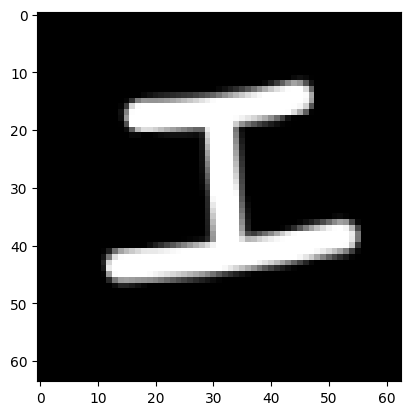

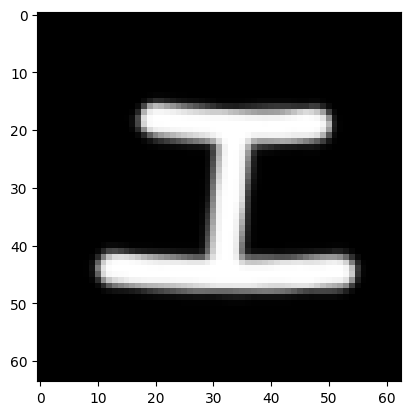

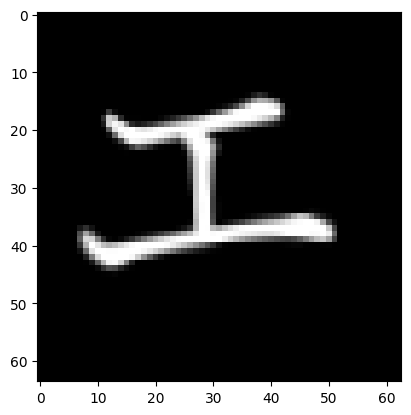

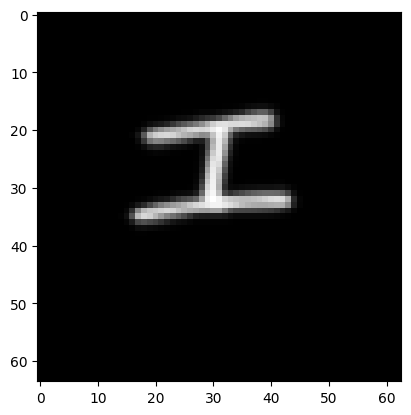

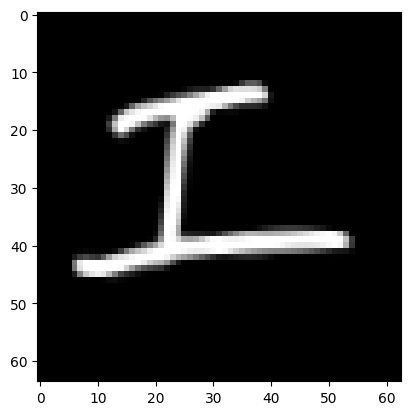

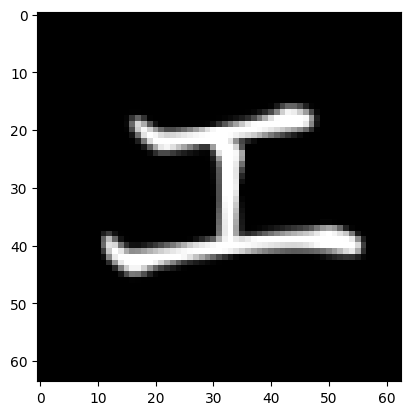

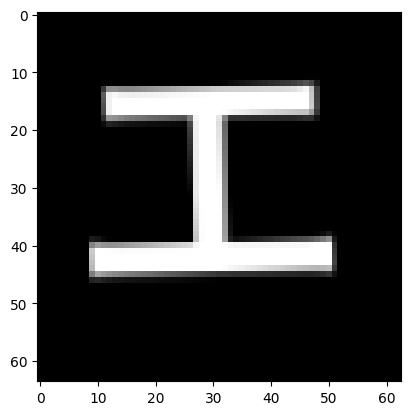

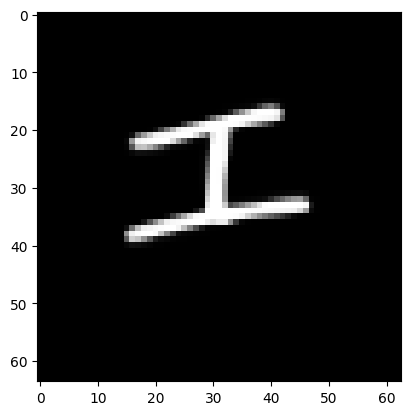

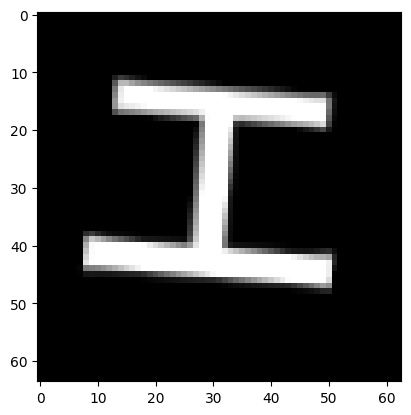

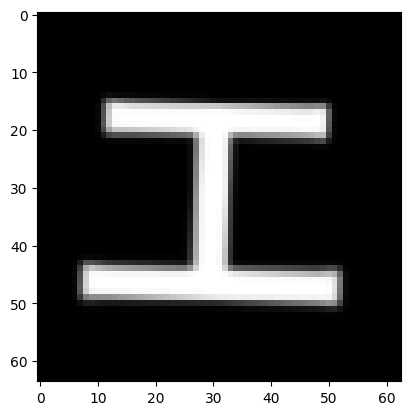

In [24]:
def ShowImageBin(img):
    image_stream = io.BytesIO(img)
    img = Image.open(image_stream)
    plt.imshow(img, cmap="binary_r")
    plt.show()
    
def ShowImages(c, n):
    i = 0
    for img in df[df["char"] == c]["image_data"]:
        ShowImageBin(img)
        i +=1
        if i == n:
            break
        
ShowImages("エ", 10)

In [16]:
converted = {str(k): f"\\u{ord(v):04x}" for k, v in newMap.items()}
print(converted)

{'3036': '\\u3001', '3037': '\\u3002', '3038': '\\uff1f', '3039': '\\uff01', '3040': '\\u300c', '3041': '\\u300d', '3042': '\\u30a2', '3043': '\\u30a4', '3044': '\\u30a6', '3045': '\\u30a8', '3046': '\\u30aa', '3047': '\\u30ab', '3048': '\\u30ac', '3049': '\\u30ad', '3050': '\\u30ae', '3051': '\\u30af', '3052': '\\u30b0', '3053': '\\u30b1', '3054': '\\u30b2', '3055': '\\u30b3', '3056': '\\u30b4', '3057': '\\u30b5', '3058': '\\u30b6', '3059': '\\u30b7', '3060': '\\u30b8', '3061': '\\u30b9', '3062': '\\u30ba', '3063': '\\u30bb', '3064': '\\u30bc', '3065': '\\u30bd', '3066': '\\u30be', '3067': '\\u30bf', '3068': '\\u30c0', '3069': '\\u30c1', '3070': '\\u30c2', '3071': '\\u30c4', '3072': '\\u30c5', '3073': '\\u30c6', '3074': '\\u30c7', '3075': '\\u30c8', '3076': '\\u30c9', '3077': '\\u30ca', '3078': '\\u30cb', '3079': '\\u30cd', '3080': '\\u30ce', '3081': '\\u30cf', '3082': '\\u30d0', '3083': '\\u30d1', '3084': '\\u30d2', '3085': '\\u30d3', '3086': '\\u30d4', '3087': '\\u30d5', '3088': '\\

In [13]:
dfExt = pd.read_parquet('/content/drive/MyDrive/ETL9B/ETL9B_Extended.parquet')
dfOG = pd.read_parquet('/content/drive/MyDrive/ETL9B/ETL9B.parquet')

In [16]:
mask = dfExt['char'].isin(CENTERED_CHARS)

def center_image_bytes(png_bytes):
    img = Image.open(io.BytesIO(png_bytes))
    arr = np.array(img, dtype=np.uint8)
    arr = CenterInk(arr)
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format="PNG")
    return buf.getvalue()

dfExt.loc[mask, 'image_data'] = dfExt.loc[mask, 'image_data'].apply(center_image_bytes)
print(f"Centered {mask.sum()} images for chars: {CENTERED_CHARS}")

Centered 412 images for chars: ['、', '。']


In [17]:
dfExt.to_parquet("drive/MyDrive/ETL9B/ETL9B_ExtendedCentered.parquet")

In [31]:
dfALL = pd.concat([dfOG, df], ignore_index=True)
dfALL.to_parquet("drive/MyDrive/ETL9B/ETL9B_ExtendedCentered.parquet")

In [33]:
print(dfALL)
print(dfOG)
print(df)
print(dfExt)

       char                                         image_data
0         あ  b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
1         い  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
2         う  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
3         え  b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
4         お  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
...     ...                                                ...
625887    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625888    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625889    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625890    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
625891    ヴ  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...

[625892 rows x 2 columns]
       char                                         image_data
0         あ  b"\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
1         い  b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
2         う  b'\x89PNG\r\n\x